In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [ ]:
import numpy as np
import pandas as pd
from src.features import cycle
from src._xgboost import search_params
from src.visualization import plot_forecast_with_train
from skforecast.recursive import ForecasterRecursive
from skforecast.preprocessing import RollingFeatures
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import joblib
import xgboost as xgb
import warnings
from skforecast.exceptions import IgnoredArgumentWarning

warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def process_data(data: pd.DataFrame):
    df = data.copy()
    df = df.asfreq('D')
    
    df['day_of_year'] = df['Дата'].dt.dayofyear
    df = cycle(df, 'Месяц', 12)
    df = cycle(df, 'day_of_year', 365)
    
    df = df.drop(columns=['Дата'])
    
    df = df.interpolate(method='akima').ffill().bfill().round(2)
    
    return df
    
def show_results(model, df_train_full, df_test, target_col, exog_cols, model_path):
    last_window = df_train_full[target_col].iloc[-30:]
    y_pred = model.predict(
                steps=len(df_test),
                exog=df_test[exog_cols],
                last_window = last_window
            )

    rmse = np.sqrt(mean_squared_error(df_test[target_col], y_pred))
    print(f'RMSE на тесте = {rmse}')

    plot_forecast_with_train(df_train_full[target_col], df_test[target_col], y_pred)
    
def fit_best_model(df_train, best_params, target_col, exog_cols, rollings):
    best_model = ForecasterRecursive(xgb.XGBRegressor(**best_params, random_state = 42), 
                                    lags = best_params['lags'],
                                    window_features=rollings)
    best_model.fit(
                y=df_train[target_col],
                exog=df_train[exog_cols]
            )
    return best_model

In [4]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [5]:
df_train_full = process_data(df_train_full)
df_train = process_data(df_train)
df_val = process_data(df_val)
df_test = process_data(df_test)

rollings = RollingFeatures(
    stats=['median'],
    window_sizes=[30]
)

Глубина 0

In [6]:
depth = 0
model_path = f'../xgboost/models/xgb_v3_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [7]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, rollings=rollings)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-13 18:59:38,272] A new study created in memory with name: no-name-52e000d4-b8e7-486f-9a3e-337f91a007c1
[I 2026-05-13 18:59:38,948] Trial 0 finished with value: 4.033230688847611 and parameters: {'lags': 2, 'n_estimators': 353, 'learning_rate': 0.005702419025200688, 'max_depth': 7, 'subsample': 0.520243591188254, 'colsample_bytree': 0.8945919796926698, 'colsample_bylevel': 0.623744964632486, 'colsample_bynode': 0.553052910735556, 'reg_alpha': 0.0002862089193732453, 'reg_lambda': 4.55584039892857, 'gamma': 0.0005781271455323453, 'min_child_weight': 7, 'max_delta_step': 16}. Best is trial 0 with value: 4.033230688847611.
[I 2026-05-13 18:59:39,497] Trial 1 finished with value: 3.7893520397974774 and parameters: {'lags': 1, 'n_estimators': 475, 'learning_rate': 0.09288998843852388, 'max_depth': 6, 'subsample': 0.47468945943212715, 'colsample_bytree': 0.52958095342181, 'colsample_bylevel': 0.4661004209837935, 'colsample_bynode': 0.7258580119901199, 'reg_alpha': 0.9004042941137244

Лучшие параметры = {'lags': 2, 'n_estimators': 583, 'learning_rate': 0.024489845604114775, 'max_depth': 3, 'subsample': 0.8759467762560336, 'colsample_bytree': 0.6173245368256023, 'colsample_bylevel': 0.4678080998665154, 'colsample_bynode': 0.8961725494488323, 'reg_alpha': 0.00014596391847154818, 'reg_lambda': 4.3938160638961624e-05, 'gamma': 0.00044940120273579315, 'min_child_weight': 11, 'max_delta_step': 8}
Лучший RMSE score = 3.382624903644448


In [8]:
best_model = fit_best_model(df_train, best_params, target_col, exog_cols, rollings)
joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v3_0']

RMSE на тесте = 2.882330202635613


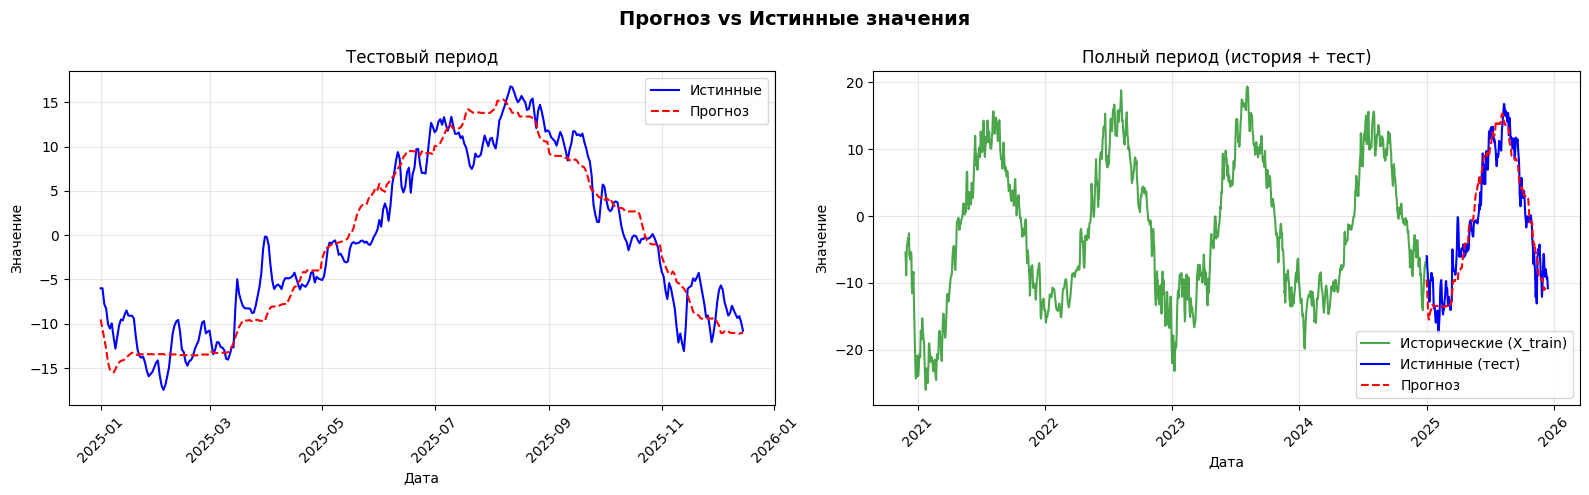

,feature,importance
0,lag_1,0.219343
4,Месяц_cos,0.215012
6,day_of_year_cos,0.186295
2,roll_median_30,0.184933
1,lag_2,0.119313
5,day_of_year_sin,0.042923
3,Месяц_sin,0.032180


In [9]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols, model_path)
importances = model.get_feature_importances()
importances

Глубина 3

In [10]:
depth = 3
model_path = f'../xgboost/models/xgb_v3_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [14]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, rollings=rollings)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-13 19:00:13,170] A new study created in memory with name: no-name-88d191dc-f474-496b-a74b-2af06dced29e
[I 2026-05-13 19:00:13,579] Trial 0 finished with value: 2.6092300158615047 and parameters: {'lags': 2, 'n_estimators': 293, 'learning_rate': 0.0011429290974141553, 'max_depth': 3, 'subsample': 0.8171016130735236, 'colsample_bytree': 0.6982962894921663, 'colsample_bylevel': 0.4353800677832529, 'colsample_bynode': 0.4276394935491337, 'reg_alpha': 4.0058637361948755, 'reg_lambda': 8.91085913149745e-05, 'gamma': 0.8279777107942258, 'min_child_weight': 15, 'max_delta_step': 7}. Best is trial 0 with value: 2.6092300158615047.
[I 2026-05-13 19:00:13,887] Trial 1 finished with value: 1.0018264666148504 and parameters: {'lags': 1, 'n_estimators': 216, 'learning_rate': 0.27059674487236574, 'max_depth': 1, 'subsample': 0.7064228060778126, 'colsample_bytree': 0.6454324457352603, 'colsample_bylevel': 0.8842296498849751, 'colsample_bynode': 0.7553037693652478, 'reg_alpha': 0.50756230160

Лучшие параметры = {'lags': 2, 'n_estimators': 402, 'learning_rate': 0.026362620087215807, 'max_depth': 7, 'subsample': 0.46457675768083084, 'colsample_bytree': 0.6352973937980662, 'colsample_bylevel': 0.4696705076000254, 'colsample_bynode': 0.4569438422429214, 'reg_alpha': 0.0006448092851567052, 'reg_lambda': 6.186330826009264e-05, 'gamma': 1.904787769314352, 'min_child_weight': 14, 'max_delta_step': 19}
Лучший RMSE score = 0.8214574102441369


In [15]:
best_model = fit_best_model(df_train, best_params, target_col, exog_cols, rollings)
joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v3_3']

RMSE на тесте = 0.9020607973006545


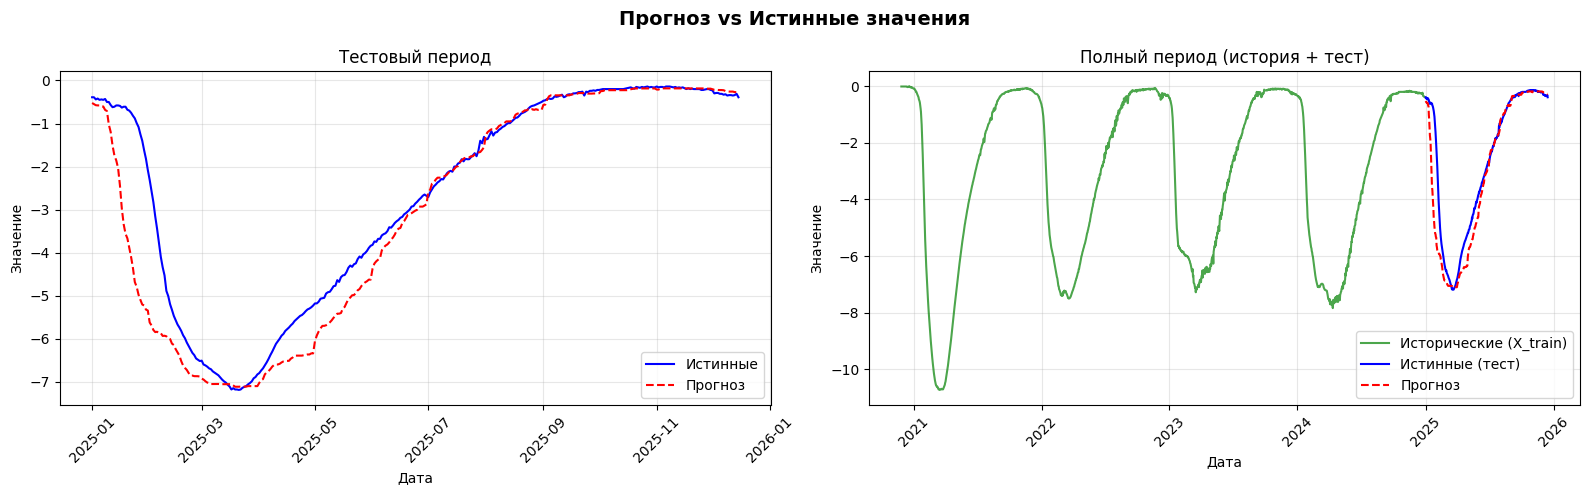

,feature,importance
3,Месяц_sin,0.210848
0,lag_1,0.202410
2,roll_median_30,0.179867
5,day_of_year_sin,0.174962
1,lag_2,0.129028
6,day_of_year_cos,0.068671
4,Месяц_cos,0.034214


In [16]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols, model_path)
importances = model.get_feature_importances()
importances

Глубина 5

In [17]:
depth = 5
model_path = f'../xgboost/models/xgb_v3_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [33]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, rollings=rollings)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-13 19:01:44,072] A new study created in memory with name: no-name-4e945071-efeb-4972-934c-1de5c9582ff1
[I 2026-05-13 19:01:44,538] Trial 0 finished with value: 0.7270784054968022 and parameters: {'lags': 1, 'n_estimators': 316, 'learning_rate': 0.0073928667878991276, 'max_depth': 4, 'subsample': 0.9712469832368615, 'colsample_bytree': 0.6454585819632752, 'colsample_bylevel': 0.4579120047388933, 'colsample_bynode': 0.5793994998033277, 'reg_alpha': 0.0031935495006852788, 'reg_lambda': 0.0004682570873737841, 'gamma': 0.05802017110395741, 'min_child_weight': 6, 'max_delta_step': 3}. Best is trial 0 with value: 0.7270784054968022.
[I 2026-05-13 19:01:45,213] Trial 1 finished with value: 0.8665980562594888 and parameters: {'lags': 3, 'n_estimators': 646, 'learning_rate': 0.005275397839036339, 'max_depth': 10, 'subsample': 0.8213648563624465, 'colsample_bytree': 0.784753737619093, 'colsample_bylevel': 0.6757949588596723, 'colsample_bynode': 0.9232644935702572, 'reg_alpha': 0.047440

Лучшие параметры = {'lags': 2, 'n_estimators': 877, 'learning_rate': 0.034661622571128516, 'max_depth': 2, 'subsample': 0.5094220375488865, 'colsample_bytree': 0.9438528687311574, 'colsample_bylevel': 0.5303948697764889, 'colsample_bynode': 0.888997577068434, 'reg_alpha': 1.272940136350105e-05, 'reg_lambda': 0.0001671279606086868, 'gamma': 2.7057900052658843e-05, 'min_child_weight': 4, 'max_delta_step': 9}
Лучший RMSE score = 0.6817116443305316


In [34]:
best_model = fit_best_model(df_train, best_params, target_col, exog_cols, rollings)
joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v3_5']

RMSE на тесте = 0.5544952933205822


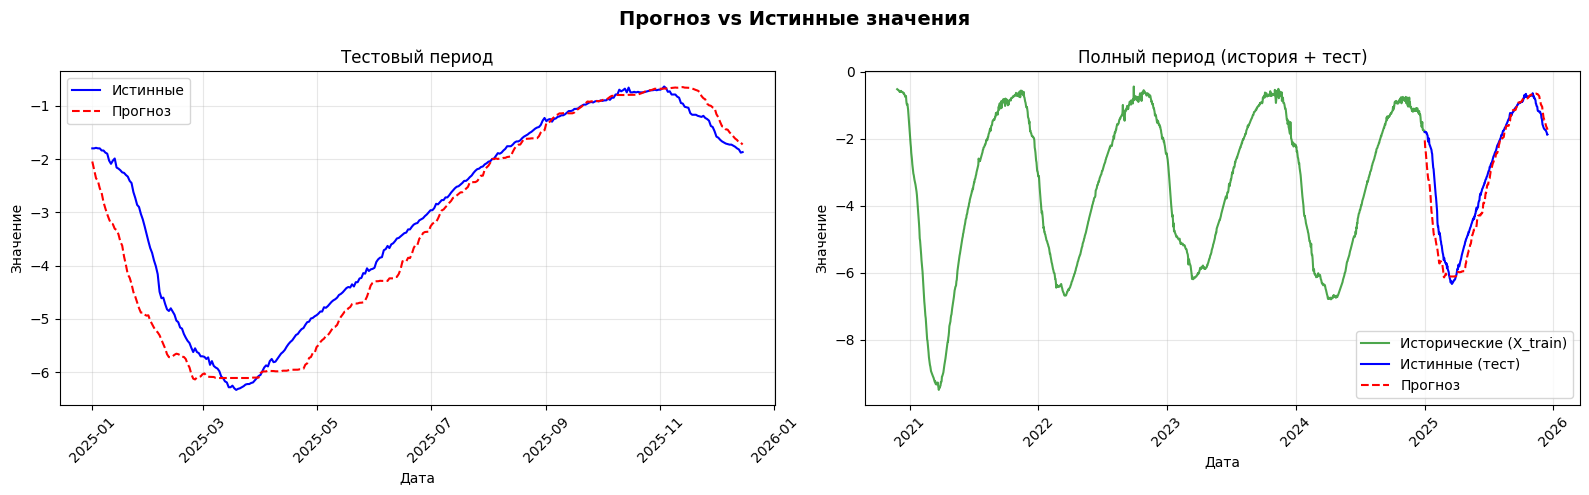

,feature,importance
0,lag_1,0.266293
5,day_of_year_sin,0.206768
3,Месяц_sin,0.197357
1,lag_2,0.170950
2,roll_median_30,0.120477
4,Месяц_cos,0.031787
6,day_of_year_cos,0.006368


In [35]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols, model_path)
importances = model.get_feature_importances()
importances

Глубина 7

In [36]:
depth = 7
model_path = f'../xgboost/models/xgb_v3_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [47]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, rollings=rollings)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-13 19:02:49,557] A new study created in memory with name: no-name-1bf2a23c-8bee-4529-b528-fb96aa8d5267
[I 2026-05-13 19:02:50,138] Trial 0 finished with value: 1.3920021857291252 and parameters: {'lags': 2, 'n_estimators': 482, 'learning_rate': 0.0009419518653187052, 'max_depth': 4, 'subsample': 0.6855499329234956, 'colsample_bytree': 0.9794510877093767, 'colsample_bylevel': 0.5005109677918598, 'colsample_bynode': 0.573218624759398, 'reg_alpha': 0.030160150320909376, 'reg_lambda': 0.0013386717614717915, 'gamma': 1.623540500248435e-05, 'min_child_weight': 6, 'max_delta_step': 4}. Best is trial 0 with value: 1.3920021857291252.
[I 2026-05-13 19:02:50,734] Trial 1 finished with value: 1.098862097823548 and parameters: {'lags': 2, 'n_estimators': 562, 'learning_rate': 0.004496116714991866, 'max_depth': 8, 'subsample': 0.6232992192901737, 'colsample_bytree': 0.8922374122309259, 'colsample_bylevel': 0.9563379845494069, 'colsample_bynode': 0.8614963432887421, 'reg_alpha': 0.0007019

Лучшие параметры = {'lags': 1, 'n_estimators': 402, 'learning_rate': 0.021410666241899586, 'max_depth': 3, 'subsample': 0.4383287694924818, 'colsample_bytree': 0.609237762562697, 'colsample_bylevel': 0.5355580166047467, 'colsample_bynode': 0.9753210373853094, 'reg_alpha': 0.03314709790557203, 'reg_lambda': 0.0004201290840630033, 'gamma': 0.0004463075737437929, 'min_child_weight': 7, 'max_delta_step': 7}
Лучший RMSE score = 0.5415938950497208


In [48]:
best_model = fit_best_model(df_train, best_params, target_col, exog_cols, rollings)
joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v3_7']

RMSE на тесте = 0.5235751074414355


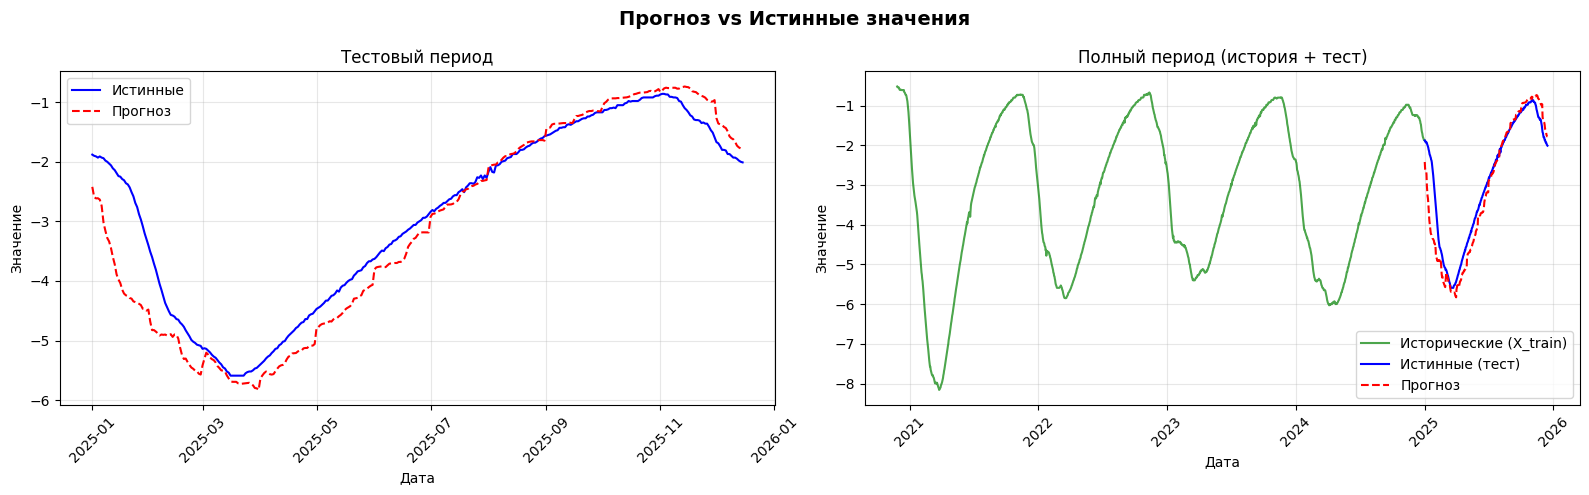

,feature,importance
4,day_of_year_sin,0.250669
0,lag_1,0.249837
2,Месяц_sin,0.236213
1,roll_median_30,0.177763
3,Месяц_cos,0.055554
5,day_of_year_cos,0.029964


In [49]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols, model_path)
importances = model.get_feature_importances()
importances

Глубина 10

In [50]:
depth = 10
model_path = f'../xgboost/models/xgb_v3_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [122]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, rollings=rollings)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-13 19:08:43,216] A new study created in memory with name: no-name-37b9103d-aa95-4726-b673-7ccf717faa62
[I 2026-05-13 19:08:43,698] Trial 0 finished with value: 0.4365175117893071 and parameters: {'lags': 3, 'n_estimators': 642, 'learning_rate': 0.0167828083248073, 'max_depth': 1, 'subsample': 0.6062923378659207, 'colsample_bytree': 0.8734168057759288, 'colsample_bylevel': 0.8791584563724076, 'colsample_bynode': 0.6232184123860341, 'reg_alpha': 0.005115611528129816, 'reg_lambda': 0.00045792754588375905, 'gamma': 0.0007926327429625495, 'min_child_weight': 8, 'max_delta_step': 14}. Best is trial 0 with value: 0.4365175117893071.
[I 2026-05-13 19:08:44,152] Trial 1 finished with value: 0.40405477276331114 and parameters: {'lags': 2, 'n_estimators': 455, 'learning_rate': 0.04781220422037178, 'max_depth': 3, 'subsample': 0.8713944437657025, 'colsample_bytree': 0.6113620154104602, 'colsample_bylevel': 0.8629264738337494, 'colsample_bynode': 0.5150371223437019, 'reg_alpha': 0.004690

Лучшие параметры = {'lags': 3, 'n_estimators': 744, 'learning_rate': 0.018428884173727986, 'max_depth': 2, 'subsample': 0.4223562200892099, 'colsample_bytree': 0.8129293700815721, 'colsample_bylevel': 0.7229190943638355, 'colsample_bynode': 0.6689243989798179, 'reg_alpha': 0.003183328111399451, 'reg_lambda': 0.0016764806646332132, 'gamma': 0.13711526015506292, 'min_child_weight': 11, 'max_delta_step': 14}
Лучший RMSE score = 0.3918665781886312


In [123]:
best_model = fit_best_model(df_train, best_params, target_col, exog_cols, rollings)
joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v3_10']

RMSE на тесте = 0.20328912586025202


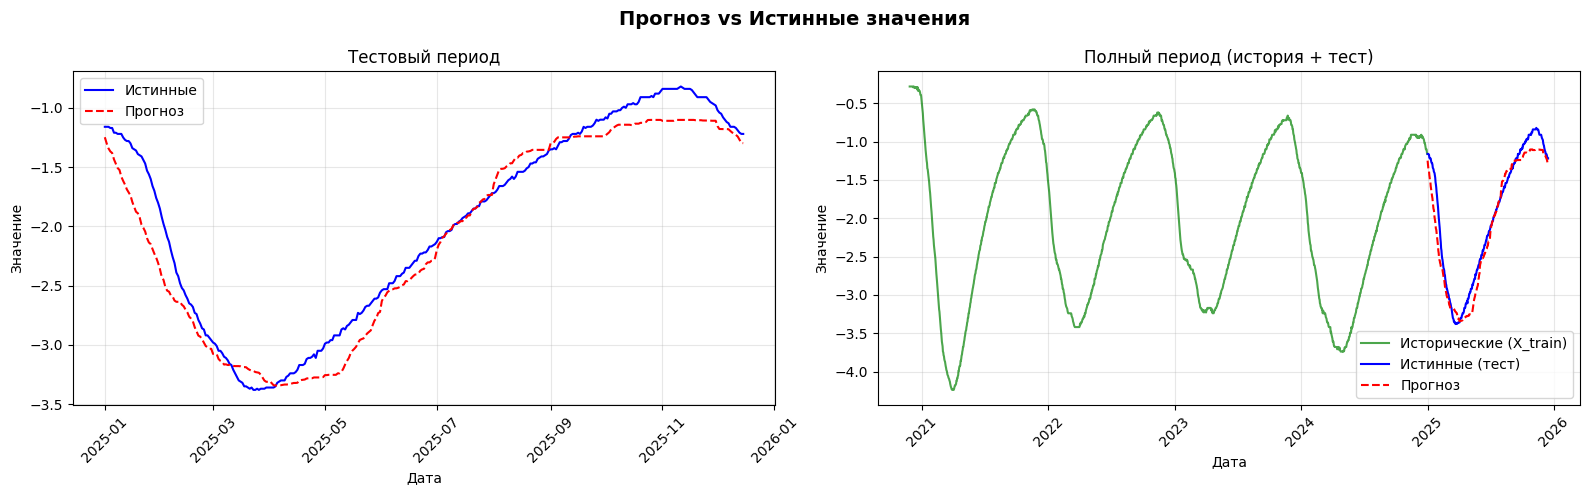

,feature,importance
2,lag_3,0.253017
4,Месяц_sin,0.181080
1,lag_2,0.164769
0,lag_1,0.139357
6,day_of_year_sin,0.138748
3,roll_median_30,0.087936
7,day_of_year_cos,0.021986
5,Месяц_cos,0.013108


In [124]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols, model_path)
importances = model.get_feature_importances()
importances